<img src="assets/belieflens-notebook-header.png" alt="BeliefLens — Measure belief. Govern uncertainty." width="760"/>

# BeliefLens SPY/SGOV authenticated workflow

## Goal

Construct and validate a private BeliefLens measurement that converts a model's native language probabilities into calibrated probabilities over application-defined states. This notebook uses Risk-on, Mixed and Risk-off, but the same workflow applies to another declared ontology and evidence domain.

## What the workflow produces

1. A versioned state model and benchmark dataset.
2. Frozen calibration, prompt-validation, conformal and test partitions.
3. A frozen prompt instrument and semantic map.
4. A cost estimate before any provider call.
5. A fitted JSON calibrator, held-out diagnostics and validation certificate.
6. A runtime-ready `measurement_profile_id` binding those assets together.

The model's printed confidence is retained only as a comparator. BeliefLens calibrates probabilities constructed from native token or complete-phrase probabilities. Code inputs are hidden by default; click a cell's disclosure control to inspect them. Outputs remain visible.

## Credentials

1. [Request a BeliefLens API key](https://demo.belieflens.org/signup).
2. Set `BELIEFLENS_API_KEY` in your environment.
3. Set your own `OPENAI_API_KEY` only when you are ready to execute the estimated job.

Your provider key is transmitted only with the approved job request and is not written into this notebook or the reproducibility archive. Never commit credentials. This workflow creates resources in your private BeliefLens workspace and the approved execution incurs provider charges.

**Further information:** [BeliefLens primer](https://belieflens.org/#/primer) · [Benchmark Lab](https://belieflens.org/#/benchmarks) · [Platform documentation](https://demo.belieflens.org/docs)


In [1]:
from pathlib import Path
from io import BytesIO
import json, os, time, uuid, zipfile
import httpx
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', 100)
BELIEFLENS_URL = os.getenv('BELIEFLENS_URL', 'https://demo.belieflens.org')
BELIEFLENS_API_KEY = os.getenv('BELIEFLENS_API_KEY')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
CUSTOM_MODEL = os.getenv('BELIEFLENS_MODEL', 'gpt-4.1-mini')
CUSTOM_RECORDS_CSV = os.getenv('BELIEFLENS_RECORDS_CSV')

bundle_candidates = [
    Path.cwd()/'data/offline_reproduction',
    Path.cwd()/'examples/notebooks/finance/data/offline_reproduction',
]
BUNDLE = next((path.resolve() for path in bundle_candidates if path.exists()), bundle_candidates[0])
assert BUNDLE.exists(), f'Frozen schema-example bundle not found: {BUNDLE}'
print('BeliefLens key configured:', bool(BELIEFLENS_API_KEY))
print('Provider key configured:', bool(OPENAI_API_KEY))


BeliefLens key configured: False
Provider key configured: False


## 1. Prepare your benchmark

A benchmark states what is being measured and supplies reference cases against which recovery can be tested. Provide a CSV through `BELIEFLENS_RECORDS_CSV`; it must contain `evidence_text`, `source_id`, and `reference_state`. Recommended provenance includes observation time, retrieval time, target, horizon, and review status. If no CSV is supplied, the frozen records are loaded only as a schema illustration and no private benchmark is created.


In [2]:
schema_records = pd.DataFrame(
    json.loads(line)
    for line in (BUNDLE/'inputs/records.jsonl').read_text().splitlines()
    if line.strip()
).rename(columns={'observation_id': 'source_id'})

custom_records = schema_records.copy() if not CUSTOM_RECORDS_CSV else pd.read_csv(CUSTOM_RECORDS_CSV)
required = {'evidence_text', 'source_id', 'reference_state'}
assert required <= set(custom_records), f'Missing columns: {sorted(required-set(custom_records))}'
custom_records[list(required) + [c for c in ['decision_date', 'partition'] if c in custom_records]].head(3)


,reference_state,evidence_text,source_id,decision_date,partition
0,Risk-on,"As of 2018-01-10, SPY returned +1.3% over five trading days and +4.0% over twenty. Trailing twen...",daily-2018-01-10,2018-01-10,calibration
1,Risk-on,"As of 2018-01-29, SPY returned +0.7% over five trading days and +6.3% over twenty. Trailing twen...",daily-2018-01-29,2018-01-29,calibration
2,Risk-off,"As of 2018-02-09, SPY returned -5.0% over five trading days and -5.2% over twenty. Trailing twen...",daily-2018-02-09,2018-02-09,calibration


## 2. Define and freeze the measurement experiment

This step declares the states, their meanings, the evidence-to-prompt rule and the allowed response phrases. It uploads the benchmark, creates held-out partitions and freezes the statistical design before model results are observed. The final two lines remain commented so inspection is safe: uncommenting them creates the private assets and requests a cost estimate, but makes no provider call.


In [3]:
def current_trace_headers():
    try:
        from opentelemetry.propagate import inject
    except ImportError:
        return {}
    headers = {}; inject(headers); return headers

def api(method, path, *, json_body=None, extra_headers=None, timeout=180):
    if not BELIEFLENS_API_KEY: raise RuntimeError('Set BELIEFLENS_API_KEY before using the configurable workflow')
    headers = current_trace_headers() | {'Authorization': f'Bearer {BELIEFLENS_API_KEY}'} | (extra_headers or {})
    response = httpx.request(method, BELIEFLENS_URL.rstrip('/') + path, headers=headers, json=json_body, timeout=timeout)
    response.raise_for_status()
    return response

def create_custom_experiment(frame):
    states = ['Risk-on', 'Mixed', 'Risk-off', 'Unsure']
    world = api('POST', '/v1/worlds', json_body={
        'name': f'Custom SPY state study {uuid.uuid4().hex[:8]}', 'domain': 'finance',
        'target': 'US broad-equity market state', 'horizon': 'declared by each evidence record', 'states': states,
        'state_definitions': {'Risk-on': 'Evidence supports broad-equity risk taking.', 'Mixed': 'Evidence is materially offsetting.',
                              'Risk-off': 'Evidence supports defensive positioning.', 'Unsure': 'Evidence is insufficient.'}
    }).json()
    dataset = api('POST', '/v1/datasets', json_body={'world_id': world['world_id'], 'name': 'Custom evidence', 'visibility': 'private_pilot', 'review_mode': 'manual'}).json()
    upload = frame.where(pd.notna(frame), None).to_dict('records')
    for start in range(0, len(upload), 250):
        api('POST', f"/v1/datasets/{dataset['id']}/observations", json_body={'records': upload[start:start+250]})
    api('POST', f"/v1/datasets/{dataset['id']}/partitions", json_body={'seed': 20260821, 'proportions': {'calibration': .4, 'prompt_validation': .2, 'conformal': .2, 'test': .2}})
    template = 'States:\n{state_definitions}\nEvidence:\n{evidence}\nAllowed responses:\n{verbalizers}'
    variants = [{'variant_id': 'evidence-first', 'template': 'Evidence:\n{evidence}\nStates:\n{state_definitions}\nAllowed responses:\n{verbalizers}'}]
    prompt = api('POST', '/v1/prompts', json_body={'world_id': world['world_id'], 'name': 'SPY semantic instrument', 'template': template,
        'verbalizers': {'Risk-on': 'Bull', 'Mixed': 'Mixed', 'Risk-off': 'Bear', 'Unsure': 'Unsure'}, 'variants': variants, 'output_contract': 'Return exactly one declared response.', 'minimum_expressed_mass': .8}).json()
    api('POST', f"/v1/datasets/{dataset['id']}/freeze"); api('POST', f"/v1/prompts/{prompt['id']}/freeze")
    estimate = api('POST', '/v1/prompt-experiments/estimates', json_body={'dataset_id': dataset['id'], 'prompt_id': prompt['id'], 'model': CUSTOM_MODEL, 'repeats': 1, 'concurrency': 4}).json()
    return world, dataset, prompt, estimate

# This mutates your private BeliefLens workspace but makes no OpenAI call. Uncomment when ready.
# world, dataset, prompt, estimate = create_custom_experiment(custom_records)
# pd.Series(estimate)


## 3. Inspect cost, then explicitly approve execution

BeliefLens calculates the planned number of model observations, estimated cost and expected duration before execution. Review `estimate` first. `approve_and_run` then sends the provider credential, prints an ASCII progress indicator, downloads the completed archive and exposes its held-out diagnostics and certificate. This is the only stage that incurs model-provider charges.


In [4]:
def approve_and_run(estimate):
    if not OPENAI_API_KEY: raise RuntimeError('Set OPENAI_API_KEY; BeliefLens does not provide or store it')
    high = float(estimate['estimated_cost_usd']['high'])
    print(f"Approving a maximum estimated provider cost of ${high:.4f}")
    job = api('POST', '/v1/jobs', json_body={'estimate_id': estimate['estimate_id'], 'hard_budget_usd': max(.01, high)},
              extra_headers={'X-OpenAI-API-Key': OPENAI_API_KEY, 'Idempotency-Key': f'notebook-{uuid.uuid4()}' }).json()
    while True:
        status = api('GET', f"/v1/jobs/{job['id']}").json()
        print(f"\r[{status['percent']:6.2f}%] {status['phase']}", end='')
        if status['status'] in {'completed', 'failed', 'cancelled'}: break
        time.sleep(3)
    print()
    if status['status'] != 'completed': raise RuntimeError(status)
    return api('GET', f"/v1/jobs/{job['id']}/result").content

# This is the only step that incurs OpenAI charges. Inspect `estimate` first, then uncomment.
# custom_archive = approve_and_run(estimate)
# with zipfile.ZipFile(BytesIO(custom_archive)) as zf:
#     custom_certificate = json.loads(zf.read('certificate.json'))
#     custom_measurements = pd.read_csv(zf.open('held_out_results.csv'))
# pd.Series({key: custom_certificate[key] for key in ['certificate_status', 'accuracy', 'mean_js_error', 'empirical_test_coverage', 'mean_prompt_perturbation_js']})


## 4. Attribute uncertainty and calibration difficulty

After a private measurement job completes, this zero-provider-call step sends only the stored measurement fields to the authenticated BeliefLens attribution analyzer. It ranks information-equivalent prompt spans, output candidates and returned top-k tokens. Positive prompt attribution means the declared perturbation reduced the corresponding badness measure; it is an experiment-specific sensitivity, not a universal causal explanation.

The underlying request uses controlled single-token response codes internally to control phrase-length and tokenization differences. BeliefLens maps those instrument tokens to declared semantic states and keeps protocol tokens separate. The reporting helper below exposes both levels: raw returned tokens are ranked by contribution to observed lexical entropy, while mapped semantic candidates are ranked by local Brier sensitivity and therefore recovery difficulty. These are local, experiment-specific sensitivities rather than universal causal claims. Structured output constrains syntax but does not itself establish semantic invariance, which requires a separate verbalizer-sensitivity test.


In [5]:
def _json_value(value, default):
    if value is None or (isinstance(value, float) and np.isnan(value)): return default
    if isinstance(value, str): return json.loads(value)
    return value

def attribution_payload_from_results(frame):
    states = ['Risk-on', 'Mixed', 'Risk-off']
    records = []
    for index, row in frame.iterrows():
        if 'calibrated_state_probabilities' in frame:
            state_probabilities = _json_value(row['calibrated_state_probabilities'], {})
            if isinstance(state_probabilities, list): state_probabilities = dict(zip(states, state_probabilities))
        else:
            state_probabilities = {state: row[f'calibrated_{state.lower().replace("-", "_")}'] for state in states}
        candidate_probabilities = _json_value(row.get('candidate_probabilities'), {})
        records.append({
            'source_id': str(row.get('source_id', row.get('scenario_id', index))),
            'reference_state': row.get('reference_state'),
            'state_probabilities': state_probabilities,
            'candidate_probabilities': candidate_probabilities,
            'candidate_state_jacobian': _json_value(row.get('candidate_state_jacobian'), {}),
            'prompt_perturbations': _json_value(row.get('prompt_perturbations'), []),
            'top_k_positions': _json_value(row.get('top_k_positions'), []),
        })
    return {'ontology': {'states': states, 'version': 'private-frozen-benchmark'}, 'records': records}

def analyze_custom_attributions(frame):
    payload = attribution_payload_from_results(frame)
    return api('POST', '/v1/attributions/analyze', json_body=payload).json()

# No provider call is made here. Run after custom_measurements has been loaded.
# custom_attribution = analyze_custom_attributions(custom_measurements)

def attribution_tables(attribution):
    mapping = attribution.get('verbalizer_mapping', {})
    candidates = pd.DataFrame(attribution['rankings']['output_candidates']).copy()
    candidates['semantic_state'] = candidates['candidate'].map(mapping).fillna(candidates['candidate'])
    candidates = candidates.sort_values('mean_absolute_local_brier_sensitivity', ascending=False).reset_index(drop=True)
    candidates.insert(0, 'recovery_rank', np.arange(1, len(candidates) + 1))
    tokens = pd.DataFrame(attribution['rankings']['top_k_tokens']).copy()
    tokens['token_type'] = np.where(tokens['semantic_state'].notna(), 'semantic instrument', 'protocol / syntax')
    tokens['meaning'] = tokens['semantic_state'].fillna('not a decision state')
    total = tokens['mean_entropy_contribution'].sum()
    tokens['share_of_ranked_entropy'] = np.where(total > 0, tokens['mean_entropy_contribution'] / total, np.nan)
    tokens = tokens.sort_values('mean_entropy_contribution', ascending=False).reset_index(drop=True)
    tokens.insert(0, 'uncertainty_rank', np.arange(1, len(tokens) + 1))
    return candidates, tokens

# Run after custom_attribution is available:
# recovery_ranking, token_uncertainty_ranking = attribution_tables(custom_attribution)
# display(recovery_ranking)
# display(token_uncertainty_ranking)


In [6]:
import matplotlib.pyplot as plt

def visualize_attributions(attribution, *, title='BeliefLens uncertainty attribution'):
    prompt = pd.DataFrame(attribution['rankings']['prompt_spans']).head(8)
    output = pd.DataFrame(attribution['rankings']['output_candidates']).head(8)
    topk = pd.DataFrame(attribution['rankings']['top_k_tokens']).head(8)
    mapping = attribution.get('verbalizer_mapping', {})
    if len(output):
        output['semantic_state'] = output['candidate'].map(mapping).fillna(output['candidate'])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    if len(prompt):
        axes[0].barh(prompt['text'][::-1], prompt['mean_js_instability'][::-1], color='#d99a2b')
    axes[0].set_title('Prompt-presentation instability')
    axes[0].set_xlabel('Mean Jensen–Shannon divergence')

    if len(output):
        axes[1].barh(output['semantic_state'][::-1], output['mean_absolute_local_brier_sensitivity'][::-1], color='#cc4c4c')
    axes[1].set_title('Semantic states affecting error')
    axes[1].set_xlabel('Mean absolute local Brier sensitivity')

    if len(topk):
        labels = topk.get('display_label', topk['token'])
        axes[2].barh(labels[::-1], topk['mean_entropy_contribution'][::-1], color='#238a8d')
    axes[2].set_title('Returned tokens contributing to uncertainty')
    axes[2].set_xlabel('Mean observed −p log(p)')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout()
    return fig, axes
# visualize_attributions(custom_attribution, title='Private benchmark attribution audit');


## 5. Use calibrated states in a separately validated strategy

The example mapping below is intentionally downstream of semantic calibration. You own and must validate the mapping from state probabilities to positions, the point-in-time return alignment, transaction costs and investment assumptions. Semantic calibration does not certify trading profitability.


In [7]:
def apply_strategy(calibrated, market_returns, *, transaction_cost_bps=5):
    """Example only: users own and validate the mapping from state probabilities to positions."""
    probabilities = np.vstack(calibrated['calibrated_state_probabilities'].map(lambda value: json.loads(value) if isinstance(value, str) else value))
    spy_weight = probabilities[:, 0] + .5 * probabilities[:, 1]
    turnover = np.abs(np.diff(spy_weight, prepend=spy_weight[0]))
    returns = spy_weight * market_returns['SPY_return'].to_numpy() + (1-spy_weight) * market_returns['safe_return'].to_numpy() - turnover * transaction_cost_bps/10_000
    return pd.DataFrame({'SPY_weight': spy_weight, 'strategy_return': returns}, index=market_returns.index)

# Supplied Massive-derived history used by the demonstration; replace it with your own point-in-time data if desired.
historical_prices = pd.read_csv(BUNDLE/'inputs/prices_total_return.csv', index_col=0, parse_dates=True)
historical_prices[['SPY', 'SGOV']].tail()
# Your merge must align each untouched-test measurement with returns occurring strictly after its observation time.
# strategy_results = apply_strategy(custom_measurements, your_aligned_future_returns)


,SPY,SGOV
2026-07-08,524.828709,144.279970
2026-07-09,529.271517,144.294331
2026-07-10,531.552769,144.323052
2026-07-13,527.483128,144.351773
2026-07-14,529.356008,144.351773


## Audit boundary

BeliefLens qualifies a declared measurement channel: it records the benchmark specification, frozen partitions, prompt version, provider observations, calibration diagnostics, uncertainty coverage and execution provenance. The portfolio rule remains a separate decision layer. Preserve the returned certificate and archive with the code and market-data vintage used in your evaluation.


## Tracing and orchestration compatibility

The normal experience requires no tracing installation. Each live measurement returns an `observability.trace_id` and, when the deployment has a trace viewer, a clickable `observability.trace_url`. Display `result['observability']` after the measurement and open the link. The visible output below also gives an immediate stage-by-stage preview.

The external-tool instructions are optional and hidden below. [Read the platform documentation](https://demo.belieflens.org/docs).

<details>
<summary><strong>Advanced: connect your own Jaeger, Grafana or Datadog backend</strong></summary>

### What can be observed

An instrumented BeliefLens deployment returns an `X-BeliefLens-Trace-Id` response header and exports W3C-linked OTLP spans for the model call, semantic map, calibration, attribution and certificate. The hosted demonstration does not expose its private observability backend. To view live spans yourself, point your BeliefLens deployment—or an instrumented LangChain workflow—at an OTLP collector you control. Raw prompts, evidence and generated text are excluded by default.

### Local Jaeger

```bash
docker run --rm --name belieflens-jaeger \
  -p 16686:16686 -p 4317:4317 -p 4318:4318 \
  jaegertracing/all-in-one:1.62.0

export BELIEFLENS_OTEL_ENABLED=true
export OTEL_SERVICE_NAME=belieflens-service
export OTEL_EXPORTER_OTLP_PROTOCOL=http/protobuf
export OTEL_EXPORTER_OTLP_ENDPOINT=http://127.0.0.1:4318
```

If BeliefLens runs in Docker on macOS, use `host.docker.internal` instead of `127.0.0.1`, or address the collector by its container name. Start the instrumented service, run a request, preserve `response.headers['X-BeliefLens-Trace-Id']`, and open [http://localhost:16686](http://localhost:16686). Select `belieflens-service` and search by that trace ID.

### Grafana Tempo or Grafana Cloud

Copy the OTLP endpoint and authorization header from the Grafana connection page into `OTEL_EXPORTER_OTLP_ENDPOINT` and `OTEL_EXPORTER_OTLP_HEADERS`. Open **Explore → Tempo**, paste the trace ID, or query `{ resource.service.name = "belieflens-service" }`. For self-hosted Tempo, place an OpenTelemetry Collector between the application and Tempo.

### Datadog

Enable the Datadog Agent's OTLP receiver or use an OpenTelemetry Collector with the Datadog exporter, and point BeliefLens at that OTLP endpoint. Open **APM → Traces**, filter `service:belieflens-service`, and search using the returned trace ID. Keep provider credentials in the agent or collector configuration, never in the notebook.

### LangChain and LangGraph: the concrete benefit

LangChain does **not** calibrate probabilities or improve the statistical estimate. `BeliefLensMeasurementRunnable` inserts an existing frozen measurement profile into an LCEL or LangGraph workflow. The profile binds the benchmark, ontology, prompt family, model, JSON calibrator and certificate; its returned decision can route the graph to continue, request review or abstain. The action can therefore be traced back to the exact validated measurement that justified it.

```python
from belieflens.integrations.langchain import BeliefLensMeasurementRunnable
measurement = BeliefLensMeasurementRunnable(
    client=client,
    measurement_profile_id=MEASUREMENT_PROFILE_ID,
    provider_api_key=OPENAI_API_KEY,
)
result = measurement.invoke(record)
```

The profile identifier binds the benchmark, ontology, prompt family, model, JSON calibrator and certificate. LangChain supplies orchestration; BeliefLens owns the probability-preserving model call and supplies calibrated semantic probabilities and the certificate; OpenTelemetry supplies the backend-neutral trace visible in Jaeger, Grafana or Datadog. See the standalone `BeliefLens_LangChain_measurement.ipynb` driver beside this notebook.

Click the collapsed-cell indicator below to inspect the logical span diagram and the exact metadata captured.

</details>


In [8]:
attribution = json.loads((BUNDLE/'attribution_result.json').read_text())


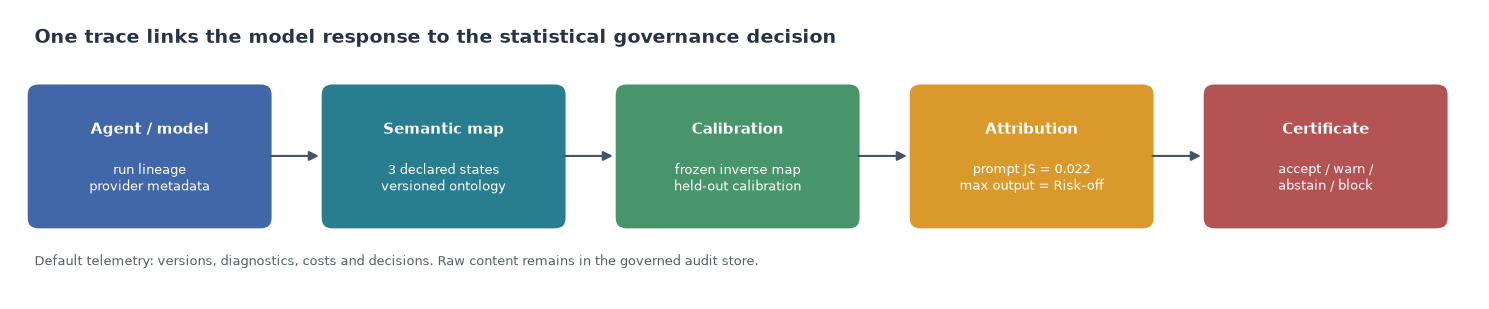

In [9]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_belieflens_trace(attribution):
    prompt = attribution['rankings']['prompt_spans'][0]
    output = attribution['rankings']['output_candidates'][0]
    stages = [
        ('Agent / model', 'run lineage\nprovider metadata', '#4267a9'),
        ('Semantic map', f"{len(attribution['ontology']['states'])} declared states\nversioned ontology", '#287d8e'),
        ('Calibration', 'frozen inverse map\nheld-out calibration', '#49956b'),
        ('Attribution', f"prompt JS = {prompt['mean_js_instability']:.3f}\nmax output = {output['candidate']}", '#d99a2b'),
        ('Certificate', 'accept / warn /\nabstain / block', '#b45353'),
    ]
    fig, ax = plt.subplots(figsize=(15, 3.2))
    ax.set_xlim(0, 15); ax.set_ylim(0, 3); ax.axis('off')
    for i, (title, detail, color) in enumerate(stages):
        x = .25 + i * 3.0
        box = FancyBboxPatch((x, .8), 2.35, 1.35, boxstyle='round,pad=.08,rounding_size=.12',
                             facecolor=color, edgecolor='white', linewidth=1.5)
        ax.add_patch(box)
        ax.text(x + 1.175, 1.75, title, color='white', weight='bold', ha='center', va='center', fontsize=10.5)
        ax.text(x + 1.175, 1.25, detail, color='white', ha='center', va='center', fontsize=9)
        if i < len(stages) - 1:
            ax.add_patch(FancyArrowPatch((x + 2.38, 1.48), (x + 2.93, 1.48), arrowstyle='-|>',
                                         mutation_scale=14, linewidth=1.5, color='#425466'))
    ax.text(.25, 2.65, 'One trace links the model response to the statistical governance decision',
            fontsize=14, weight='bold', color='#243447')
    ax.text(.25, .35, 'Default telemetry: versions, diagnostics, costs and decisions. Raw content remains in the governed audit store.',
            fontsize=9.5, color='#52616b')
    fig.tight_layout()
    return fig

trace_figure = visualize_belieflens_trace(attribution)
trace_figure;


In [10]:
trace_preview = pd.DataFrame([
    {'span': 'agent/model', 'parent': 'workflow', 'observable result': 'model, usage, latency and provider metadata', 'raw content exported by default': False},
    {'span': 'semantic_map.apply', 'parent': 'workflow', 'observable result': 'ontology and semantic-map versions', 'raw content exported by default': False},
    {'span': 'calibration.apply', 'parent': 'workflow', 'observable result': 'calibrator, partition and coverage diagnostics', 'raw content exported by default': False},
    {'span': 'attribution.analyze', 'parent': 'workflow', 'observable result': 'prompt JS, output sensitivity and top-k completeness', 'raw content exported by default': False},
    {'span': 'certificate.evaluate', 'parent': 'workflow', 'observable result': 'accept, warn, abstain or block', 'raw content exported by default': False},
])
trace_preview


,span,parent,observable result,raw content exported by default
0,agent/model,workflow,"model, usage, latency and provider metadata",False
1,semantic_map.apply,workflow,ontology and semantic-map versions,False
2,calibration.apply,workflow,"calibrator, partition and coverage diagnostics",False
3,attribution.analyze,workflow,"prompt JS, output sensitivity and top-k completeness",False
4,certificate.evaluate,workflow,"accept, warn, abstain or block",False


In [11]:
langchain_integration_preview = pd.DataFrame([
    ('BeliefLensMeasurementRunnable', 'calls one frozen measurement profile without refitting it', 'calibrated state probabilities inside the chain'),
    ('Measurement profile', 'binds benchmark, ontology, prompt, model, JSON calibrator, and certificate', 'prevents incompatible assets being mixed'),
    ('Conditional graph edge', 'routes on the returned certificate decision', 'continue, review, abstain, or block'),
    ('OpenTelemetry context', 'joins agent, model, semantic map, calibration, and action spans', 'one trace across vendor tools'),
], columns=['integration component', 'what it does', 'practical gain'])
langchain_integration_preview


,LangChain callback field,captured,purpose
0,run_id / parent_run_id,yes,joins nested chains and tools to the trace
1,benchmark / ontology / prompt version,yes,identifies the statistical instrument
2,"model, usage, latency, finish reason",yes,operational provenance
3,provider-native log probabilities,when supplied,input to semantic mapping and attribution
4,"raw prompt, evidence and generation",no by default,requires explicit governed content capture
